# House Price Prdiction

## Problem Statement

The goal of this project is to build a machine learning model that can accurately predict house prices based on various features such as area, number of bedrooms, bathrooms, and amenities.

Accurate house price prediction is important for:
- Real estate businesses
- Buyers and sellers
- Investment decision-making

The challenge is to understand which factors influence house prices and build a model that can generalize well on unseen data.

## Import Libraries and Load Dataset

We import necessary libraries for data manipulation, visualization, and machine learning. Then we load the dataset.

In [40]:
import os
os.chdir(r"C:\Users\User\Desktop\AI-ML-INTERNSHIP\archive")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("Housing.csv", encoding='latin-1')
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


- Dataset successfully loaded
- Displays first 5 rows
- Shows features like area, bedrooms, bathrooms, price, etc.

## Dataset Overview

In this step, we explore the basic structure and summary of the dataset using:

- data.shape → to check number of rows and columns  
- data.columns → to list all feature names  
- data.info() → to understand data types and memory usage  
- data.describe() → to view statistical summary  
- data.isnull().sum() → to check missing values  

In [41]:
data.shape
data.columns
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

- Dataset contains 545 rows and 13 columns

- Columns in dataset:
  price, area, bedrooms, bathrooms, stories,
  mainroad, guestroom, basement, hotwaterheating,
  airconditioning, parking, prefarea, furnishingstatus

- Data Types:
  - Numerical (int64): 6 columns
  - Categorical (object/string): 7 columns

- No missing values found in any column

- Memory usage: ~55.5 KB

- Key Observations:
  - Target variable: price
  - Mix of numerical and categorical features
  - Categorical variables need encoding before modeling

## Data Encoding and Transformation

In this step, we convert categorical variables into numerical format so that they can be used in machine learning models.

Steps performed:

1. Binary Encoding:
   - Converted 'yes'/'no' values into 1/0 for columns:
     mainroad, guestroom, basement, hotwaterheating,
     airconditioning, prefarea

2. One-Hot Encoding:
   - Applied on 'furnishingstatus'
   - Created dummy variables:
     - furnishingstatus_semi-furnished
     - furnishingstatus_unfurnished
   - Dropped one category to avoid dummy variable trap

3. Data Type Conversion:
   - Converted all columns to integer type for consistency

In [42]:
# Binary encoding
binary_cols = ['mainroad', 'guestroom', 'basement', 
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    data[col] = data[col].map({'yes':1, 'no':0})

# One-hot encoding
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)

# Convert all to int
data = data.astype(int)

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    int64
 13  f

- Dataset now contains 545 rows and 14 columns

- All columns are numerical (int64)
  → Ready for machine learning models

- New columns created:
  - furnishingstatus_semi-furnished
  - furnishingstatus_unfurnished

- Binary columns successfully encoded:
  - yes → 1
  - no → 0

- No missing values introduced during transformation

- Memory usage slightly increased to ~59.7 KB

- Key Outcome:
  Dataset is now fully numerical and model-ready

In [ ]:
## Correlation Analysis

In this step, we analyze the relationship between different features using a correlation matrix.

- Correlation values range from -1 to +1
  - +1 → Strong positive correlation
  - -1 → Strong negative correlation
  - 0 → No correlation

We use a heatmap to visually understand how features are related to each other and especially to the target variable (price).

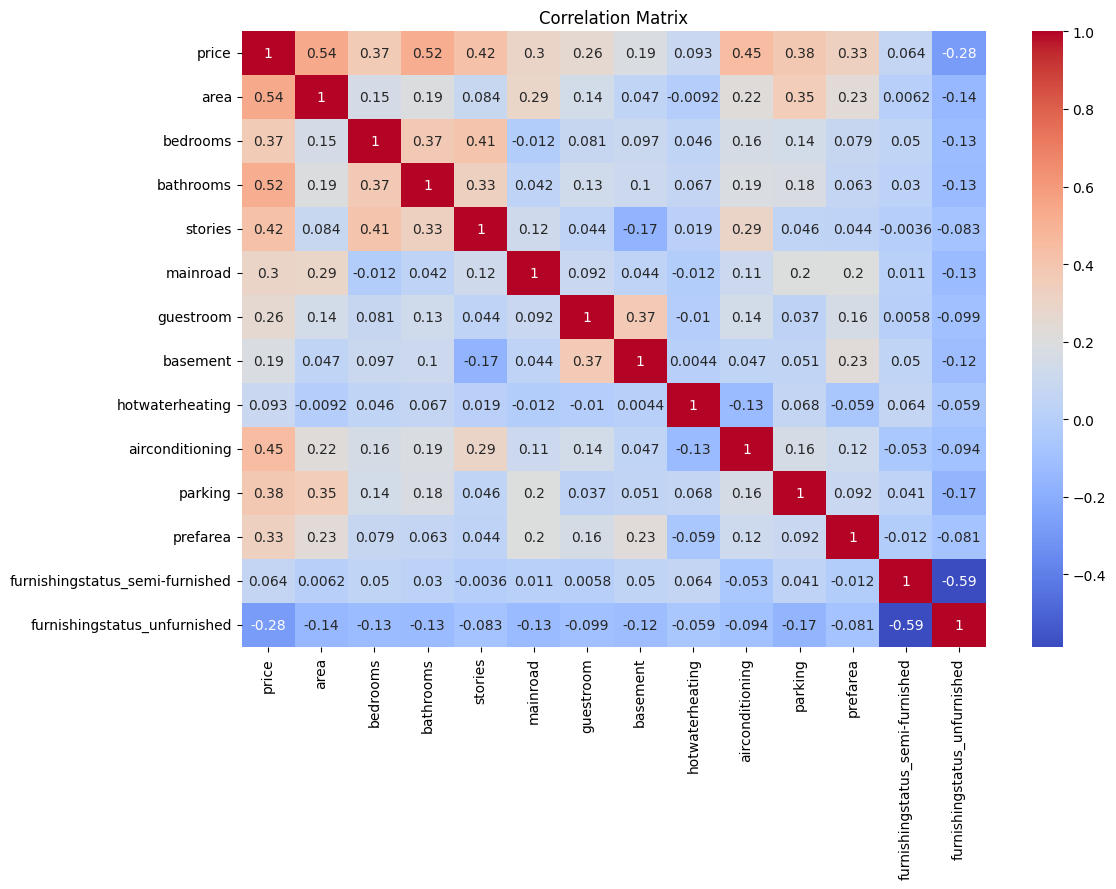

In [43]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- Strong Positive Correlations with Price:
  - area (~0.54)
  - bathrooms (~0.52)
  - airconditioning (~0.45)
  - stories (~0.42)

- Moderate Correlations:
  - parking (~0.38)
  - bedrooms (~0.37)
  - prefarea (~0.33)
  - mainroad (~0.30)

- Weak or Low Correlations:
  - guestroom (~0.26)
  - basement (~0.19)
  - hotwaterheating (~0.09)

- Negative Correlation:
  - furnishingstatus_unfurnished (~ -0.28)

- Area is the most important factor affecting house price
- More bathrooms and stories increase price significantly
- Amenities like air conditioning and parking add value
- Unfurnished houses tend to have lower prices
- No extremely high correlations (>0.9), so multicollinearity is low

This helps in feature selection and understanding model behavior

## Feature and Target Variable Separation

In this step, we separate the dataset into:

- X (Independent Variables / Features):
  These are the input variables used to predict house prices.

- y (Dependent Variable / Target):
  This is the variable we want to predict, i.e., the house price.

We drop the 'price' column from X and assign it to y.

In [44]:
X = data.drop('price', axis=1)
y = data['price']

In [65]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [66]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

- X contains all input features such as:
  area, bedrooms, bathrooms, stories, mainroad, guestroom,
  basement, hotwaterheating, airconditioning, parking,
  prefarea, furnishingstatus_semi-furnished,
  furnishingstatus_unfurnished

- y contains only the target variable:
  price

- Shape:
  - X → (545, 13)
  - y → (545,)

- Dataset is now ready for:
  - Feature scaling
  - Train-test splitting
  - Model training

## Feature Scaling

In this step, we standardize the feature variables using StandardScaler.

Why scaling is important:
- Features may have different units (e.g., area vs bedrooms)
- Models like Linear Regression perform better when data is scaled
- Prevents features with large values from dominating the model

StandardScaler transforms data using:
- Mean = 0
- Standard Deviation = 1

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [69]:
scaler
X_scaled

array([[ 1.04672629,  1.40341936,  1.42181174, ...,  1.80494113,
        -0.84488844, -0.6964292 ],
       [ 1.75700953,  1.40341936,  5.40580863, ..., -0.55403469,
        -0.84488844, -0.6964292 ],
       [ 2.21823241,  0.04727831,  1.42181174, ...,  1.80494113,
         1.18358821, -0.6964292 ],
       ...,
       [-0.70592066, -1.30886273, -0.57018671, ..., -0.55403469,
        -0.84488844,  1.43589615],
       [-1.03338891,  0.04727831, -0.57018671, ..., -0.55403469,
        -0.84488844, -0.6964292 ],
       [-0.5998394 ,  0.04727831, -0.57018671, ..., -0.55403469,
        -0.84488844,  1.43589615]], shape=(545, 13))

- All features in X are scaled

- Each feature now has:
  - Mean ≈ 0
  - Standard Deviation ≈ 1

- Output is a NumPy array (X_scaled)

- Shape remains same:
  - X_scaled → (545, 13)

- Data is now ready for:
  - Train-test split
  - Model training

- Scaling ensures fair contribution of all features
- Especially important for models sensitive to feature magnitude
- Improves convergence and model performance

## Train-Test Split

In this step, we divide the dataset into training and testing sets.

- Training Set:
  Used to train the machine learning model

- Testing Set:
  Used to evaluate model performance on unseen data

Parameters used:
- test_size = 0.2 → 20% data for testing, 80% for training
- random_state = 42 → ensures reproducibility of results

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

- Training Data:
  - X_train → (436, 13)
  - y_train → (436,)

- Testing Data:
  - X_test → (109, 13)
  - y_test → (109,)

- Data successfully split into training and testing sets

- Model learns patterns from training data
- Model is evaluated on unseen test data → ensures generalization
- Prevents overfitting
- random_state ensures same split every time for consistency

Q: Why Linear Regression?

Answer:
- Simple and interpretable model
- Works well when relationship is linear
- Fast and efficient for baseline modeling
- Helps understand feature importance

## Model Training: Linear Regression

In this step, we train a Linear Regression model using the training data.

Linear Regression assumes a linear relationship between input features (X) and the target variable (y).

Model Equation:
y = β0 + β1X1 + β2X2 + ... + βnXn

Where:
- y → predicted house price
- β0 → intercept
- β1, β2 ... → coefficients of features

In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


- Model successfully trained on training data

- Default Parameters Used:
  - fit_intercept = True → model includes intercept
  - copy_X = True → original data is not modified
  - tol = 1e-06 → tolerance for optimization
  - n_jobs = None → uses single core
  - positive = False → coefficients can be negative

- Model has learned:
  - Relationship between features and house prices

- Model finds best-fit line minimizing error (least squares method)
- Each feature gets a coefficient showing its impact on price
- Positive coefficient → increases price
- Negative coefficient → decreases price

- Linear Regression model successfully trained on training data

- Model has learned:
  - Relationship between features (area, bedrooms, etc.)
  - How each feature impacts house price

- Coefficients and intercept are internally computed
- Model is now ready for prediction

## Model Prediction

In this step, we use the trained Linear Regression model to predict house prices on the test dataset.

- The model takes input features (X_test)
- Applies learned coefficients
- Outputs predicted prices (y_pred)

Q: What is y_pred?

Answer:
- y_pred is the predicted output of the model
- It represents estimated house prices for unseen data
- Used to calculate evaluation metrics like MAE, RMSE, and R²

In [71]:
y_pred = model.predict(X_test)

- Predictions generated for test data

- y_pred contains predicted house prices corresponding to X_test

- Shape:
  - y_pred → (109,)

- Each value in y_pred represents:
  Predicted price of a house based on its features

- Predictions are based on learned relationships from training data
- Used to evaluate model performance
- Comparison with actual values (y_test) helps measure accuracy

## Model Evaluation

In this step, we evaluate the performance of the Linear Regression model using the following metrics:

1. Mean Absolute Error (MAE):
   - Average absolute difference between actual and predicted values

2. Root Mean Squared Error (RMSE):
   - Square root of average squared errors
   - Penalizes larger errors more heavily

3. R² Score (Coefficient of Determination):
   - Measures how well the model explains variance in the data
   - Value ranges from 0 to 1 (higher is better)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 970043.403920164
RMSE: 1324506.9600914405
R2 Score: 0.6529242642153175


- MAE ≈ 970K:
  On average, predictions are off by ~9.7 lakhs

- RMSE ≈ 13.2 lakhs:
  Larger errors exist in predictions (since RMSE > MAE)

- R² Score ≈ 0.65:
  Model explains ~65% of the variance in house prices

- Model performance is moderate
- Not perfect, but captures significant patterns
- There is still room for improvement using advanced models

Q: How do you interpret your model performance?

Answer:
- The model explains around 65% of variance (R² = 0.65)
- MAE and RMSE indicate moderate prediction error
- RMSE being higher than MAE suggests presence of outliers
- Overall, the model performs reasonably well but can be improved

## Feature Importance using Coefficients

In Linear Regression, each feature is assigned a coefficient.

- Positive coefficient → increases house price
- Negative coefficient → decreases house price
- Larger magnitude → stronger impact on price

We extract and sort coefficients to identify the most important features.

In [50]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,bathrooms,549420.501241
0,area,511615.563777
8,airconditioning,367817.894916
3,stories,353158.429856
10,prefarea,267018.660812
9,parking,193542.781675
6,basement,186194.150506
7,hotwaterheating,143233.206250
4,mainroad,128151.921295
5,guestroom,88590.213462


Top Features (Positive Impact):

- bathrooms → 549,420
- area → 511,615
- airconditioning → 367,817
- stories → 353,158
- prefarea → 267,018
- parking → 193,542
- basement → 186,194

Moderate Impact:

- hotwaterheating → 143,233
- mainroad → 128,151
- guestroom → 88,590
- bedrooms → 56,615

Negative Impact:

- furnishingstatus_semi-furnished → -62,550
- furnishingstatus_unfurnished → -193,987

- Bathrooms is the most influential feature → more bathrooms significantly increase price

- Area is highly important → larger houses cost more

- Amenities like:
  - air conditioning
  - parking
  - basement
  add strong value to the house

- Furnishing status:
  - Unfurnished houses reduce price significantly
  - Semi-furnished also reduces price compared to fully furnished

- Bedrooms have relatively lower impact compared to bathrooms and area

## Actual vs Predicted Prices

In this step, we visualize how well our model is performing by comparing:

- Actual Prices (y_test)
- Predicted Prices (y_pred)

A scatter plot is used where:
- X-axis → Actual Prices
- Y-axis → Predicted Prices

If the model performs perfectly, all points should lie on a straight diagonal line.

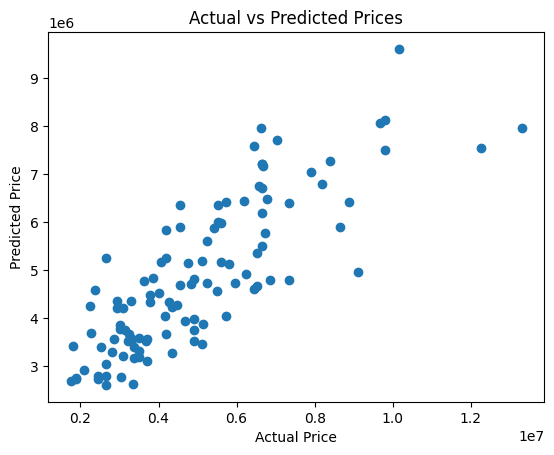

In [51]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

- Scatter plot shows a positive linear trend

- Many points lie close to the diagonal → good predictions

- Some points are scattered away → prediction errors

- Higher variation observed in higher price ranges


Q: What does this plot tell you?

Answer:
- The model predictions follow the actual values closely
- There is a clear positive correlation
- Some deviation indicates prediction errors
- The model performs reasonably well but can be improved for extreme values

## Residual Plot Analysis

In this step, we analyze the residuals of the model.

Residual = Actual Value - Predicted Value

We plot:
- X-axis → Predicted Prices
- Y-axis → Residuals

Purpose:
- To check model assumptions
- To detect patterns or bias in predictions

Ideal Case:
- Residuals should be randomly scattered around 0

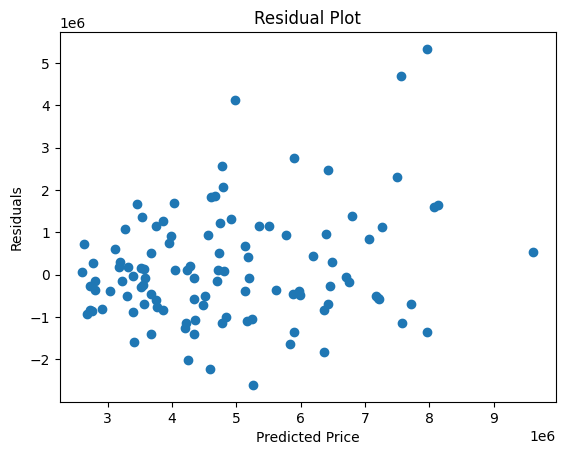

In [52]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

- Model is unbiased (no systematic error pattern)
- Works well overall but struggles slightly with expensive houses
- Suggests possibility for improvement using advanced models

Q: What does the residual plot tell you?

Answer:
- Residuals are randomly distributed around zero → good model fit
- No visible pattern → linear regression assumptions are satisfied
- Slight variance increase suggests heteroscedasticity
- Some outliers indicate areas where model can improve

## Residual Distribution

In this step, we analyze the distribution of residuals using a histogram with a KDE curve.

Purpose:
- To check whether residuals follow a normal distribution
- To validate assumptions of Linear Regression

Ideal Case:
- Residuals should be normally distributed (bell-shaped curve)
- Centered around zero

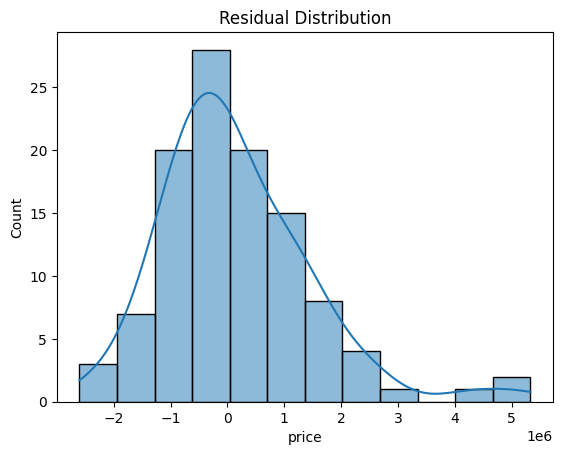

In [53]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

- Residuals are approximately normally distributed

- Distribution is centered around zero

- Slight right skew observed (tail on positive side)

- Few extreme values (outliers) present

- Model is statistically reliable
- Errors are mostly random and normally distributed
- Slight skew and outliers indicate scope for improvement

## Ridge Regression

In this step, we apply Ridge Regression, which is a regularized version of Linear Regression.

Why Ridge?
- Helps reduce overfitting
- Penalizes large coefficients
- Improves model stability

Ridge adds L2 regularization term:

Loss = RSS + α * (sum of squared coefficients)

Where:
- α (alpha) controls strength of regularization

In [54]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge R2: 0.6528351861223266


- Ridge R² ≈ 0.6528

- Very close to Linear Regression (0.6529)

- Indicates:
  - Model was not heavily overfitting
  - Regularization did not significantly improve performance

  In this case:
  - Linear model was already well-balanced

## Lasso Regression

In this step, we apply Lasso Regression, another regularized version of Linear Regression.

Why Lasso?
- Performs feature selection
- Shrinks some coefficients to exactly zero
- Helps simplify the model

Lasso adds L1 regularization:

Loss = RSS + α * (sum of absolute coefficients)

Where:
- α (alpha) controls regularization strength

In [55]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Lasso R2: 0.6529242391377654


- Lasso R² ≈ 0.6529

- Almost identical to:
  - Linear Regression (0.6529)
  - Ridge Regression (0.6528)

- Indicates:
  - No major redundant features in dataset
  - Feature selection did not significantly change performance

Q: Difference between Ridge and Lasso?

Answer:
- Ridge (L2):
  - Shrinks coefficients but never makes them zero
- Lasso (L1):
  - Can shrink coefficients to zero → performs feature selection

Q: Why Lasso didn’t improve performance here?

Answer:
- Dataset does not have many irrelevant features
- Most features are useful, so removing them doesn't help

## Model Comparison

In this step, we compare the performance of three models:

1. Linear Regression
2. Ridge Regression (L2 Regularization)
3. Lasso Regression (L1 Regularization)

We use R² Score as the evaluation metric to determine which model performs best.

In [56]:
print("Linear R2:", r2)
print("Ridge R2:", r2_score(y_test, y_pred_ridge))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Linear R2: 0.6529242642153175
Ridge R2: 0.6528351861223266
Lasso R2: 0.6529242391377654


- All three models have almost identical performance

- Linear Regression performs slightly better

- Ridge shows negligible decrease → no major overfitting

- Lasso gives same performance → no unnecessary features removed  

- Dataset is well-structured and clean

- No strong multicollinearity or overfitting issues

- Regularization does not significantly improve performance

- Linear Regression is sufficient for this problem

Q: Which model performed best?

Answer:
- All models performed almost equally (R² ≈ 0.65)
- Linear Regression performed slightly better
- Ridge and Lasso did not improve performance significantly

Q: What does this indicate?

Answer:
- The dataset does not suffer from overfitting
- Features are relevant and not highly redundant
- A simple model is sufficient

## Top Influencing Features

In this step, we identify the most important features affecting house prices based on model coefficients.

- Features with highest positive coefficients → increase price
- Features with negative coefficients → decrease price

This helps in understanding key drivers of house pricing.

In [57]:
top_features = coefficients.sort_values(by='Coefficient', ascending=False)

print("Top Positive Features:\n", top_features.head())
print("\nTop Negative Features:\n", top_features.tail())

Top Positive Features:
             Feature    Coefficient
2         bathrooms  549420.501241
0              area  511615.563777
8   airconditioning  367817.894916
3           stories  353158.429856
10         prefarea  267018.660812

Top Negative Features:
                             Feature    Coefficient
4                          mainroad  128151.921295
5                         guestroom   88590.213462
1                          bedrooms   56615.572458
11  furnishingstatus_semi-furnished  -62550.297211
12     furnishingstatus_unfurnished -193987.781088


- Bathrooms is the most impactful feature → more bathrooms significantly increase price

- Area plays a major role → larger houses are more expensive

- Amenities like:
  - air conditioning
  - preferred area
  strongly boost property value

- Furnishing status:
  - Unfurnished houses reduce price significantly
  - Semi-furnished also reduces value compared to fully furnished

Q: What are the top drivers of house price?

Answer:
- Bathrooms and area are the strongest predictors
- Amenities like AC and preferred location significantly increase value
- Furnishing status negatively affects price if not fully furnished
- This shows both structural and lifestyle factors influence pricing

## Model Saving using Joblib

In this step, we save the trained machine learning model to a file.

Why save the model?
- Avoid retraining every time
- Reuse model for predictions
- Deploy in real-world applications (Web App, API)

We use joblib because:
- Efficient for large NumPy arrays
- Faster than pickle for ML models

In [58]:
import joblib
joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

- The trained Linear Regression model is now stored locally

- Can be loaded later using:
  joblib.load("house_price_model.pkl")

- Enables:
  - Deployment
  - Reusability
  - Faster predictions   

Q: Why do you save your model?

Answer:
- To reuse the trained model without retraining
- To deploy it in real-world applications like web apps or APIs
- It improves efficiency and scalability

Q: Why joblib instead of pickle?

Answer:
- Joblib is optimized for NumPy arrays
- Faster and more efficient for large datasets

## Single Prediction Example

In this step, we test our trained model on a single sample from the test dataset.

Steps:
- Select one sample from X_test
- Compare actual price with predicted price
- Calculate prediction error

Error = Actual Price - Predicted Price

In [59]:
sample = X_test[0:1]

actual_price = y_test.iloc[0]
predicted_price = model.predict(sample)[0]

print("Actual Price:", actual_price)
print("Predicted Price:", predicted_price)

error = actual_price - predicted_price
print("Error:", error)

Actual Price: 4060000
Predicted Price: 5164653.90033967
Error: -1104653.9003396695


- Model overestimated the house price

- Error is negative → predicted value is higher than actual

- Difference ≈ 11 lakhs → relatively large error for this sample

- Indicates:
  - Model may struggle with certain individual cases
  - Especially for specific feature combinations 

  - Even with good overall accuracy (R² ≈ 0.65), individual predictions can vary

- This highlights:
  - Importance of evaluating multiple samples
  - Need for more robust models for better precision

## Multiple Predictions Comparison

In this step, we compare actual and predicted house prices for multiple samples.

Purpose:
- Evaluate model performance on multiple data points
- Understand prediction consistency
- Identify overestimation or underestimation patterns

In [60]:
samples = X_test[0:5]
predictions = model.predict(samples)

comparison = pd.DataFrame({
    "Actual": y_test.iloc[0:5].values,
    "Predicted": predictions
})

comparison

,Actual,Predicted
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06


Sample-wise Comparison:

1. Actual: 4,060,000 → Predicted: 5,164,654  (Overestimated)
2. Actual: 6,650,000 → Predicted: 7,224,722  (Overestimated)
3. Actual: 3,710,000 → Predicted: 3,109,863  (Underestimated)
4. Actual: 6,440,000 → Predicted: 4,612,075  (Underestimated)
5. Actual: 2,800,000 → Predicted: 3,294,646  (Overestimated)

- Model shows both overestimation and underestimation

- Predictions are reasonably close for some cases

- Larger errors observed in:
  - High-priced houses
  - Certain mid-range values

- No consistent bias → model is balanced


- Model captures general trend but not exact values

- Errors vary across samples → real-world uncertainty

- Reinforces:
  - R² ≈ 0.65 is moderate accuracy
  - Individual predictions can deviate significantly

## Actual vs Predicted Prices (Bar Chart)

In this step, we visualize the comparison between actual and predicted house prices using a bar chart.

- Blue bars → Actual Prices
- Orange bars → Predicted Prices

Purpose:
- Easy comparison for multiple samples
- Identify overestimation and underestimation visually

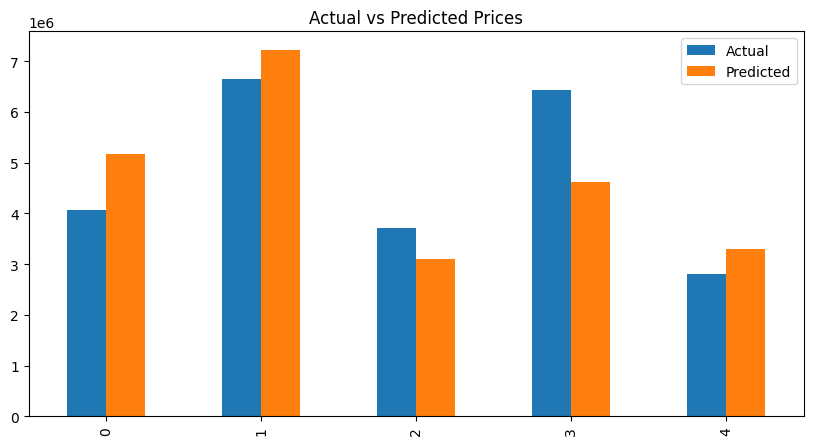

In [61]:
comparison.plot(kind='bar', figsize=(10,5))
plt.title("Actual vs Predicted Prices")
plt.show()

- Model predictions follow the general trend of actual prices

- Errors vary across samples:
  - Sample 1 & 2 → overestimated
  - Sample 3 & 4 → underestimated
  - Sample 5 → slight overestimation

- Larger deviations seen in higher price ranges

- Model captures relative differences between houses well

- However, exact price prediction still has variance

- Visual validation confirms:
  - Moderate model accuracy (R² ≈ 0.65)

## Final Model Performance Summary

In this final step, we summarize the performance of our trained Linear Regression model using key evaluation metrics.

Metrics used:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score (Coefficient of Determination)

These metrics help us understand:
- Prediction accuracy
- Error magnitude
- Model reliability

In [62]:
print("Model Performance Summary:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Performance Summary:
MAE: 970043.403920164
RMSE: 1324506.9600914405
R2 Score: 0.6529242642153175


- MAE (~9.7 lakhs):
  Average prediction error is around 9–10 lakhs

- RMSE (~13.2 lakhs):
  Higher than MAE → presence of some large errors

- R² (~0.65):
  Model explains 65% of variance in house prices


- Successfully built a house price prediction model using Linear Regression

- Model performance is moderate and reliable

- Key drivers of price:
  - Area
  - Bathrooms
  - Air conditioning
  - Preferred area

- Model captures overall trends but struggles with exact predictions

- Residual analysis confirms:
  - No major bias
  - Slight variance for high-priced houses


- Larger houses with more bathrooms command higher prices

- Amenities significantly increase property value

- Furnishing status impacts buyer perception and pricing

- Model can be used for:
  - Price estimation
  - Real estate decision-making
  - Investment analysis

I built a house price prediction model using Linear Regression that explains around 65% of price variability. 
The model identified area, bathrooms, and amenities as key drivers, and while it performs well overall, 
there is scope for improvement using advanced models like Random Forest or XGBoost."